# Exploratory Data Analysis

Aqui pretendo explicitar todos os achados na parte de engenharia de dados que apoiam as decisões tomadas para realizar a calibração e teste adequado dos modelos. 

In [93]:
from pathlib import Path
import numpy as np
import os

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)


In [127]:
import pandas as pd

path_calendar = PROJECT_ROOT / "data/calendars/03_refined/Calendar_BR_dim.parquet"
path_fwd = PROJECT_ROOT / "data/03_refined/b3/forwards/b3_forwards_di1_refined.parquet"
path_swp = PROJECT_ROOT / "data/03_refined/b3/swaps/b3_swaps_dipre_refined.parquet"
path_bnd = PROJECT_ROOT / "data/04_feature/curve_factory/public_bonds/mart_public_bonds_curve_inputs_dimension_batch.parquet"

df_calendar = pd.read_parquet(path_calendar)
df_fwds_DI = pd.read_parquet(path_fwd)
df_swps_DI = pd.read_parquet(path_swp)
df_candidates = pd.read_parquet(path_bnd)

df_calendar["date"] = pd.to_datetime(
    df_calendar["date"], utc=True
).dt.tz_convert(None).dt.normalize()

df_candidates["date"] = pd.to_datetime(
    df_candidates["ref_date"], utc=True
).dt.tz_convert(None).dt.normalize()

df_fwds_DI["date"] = pd.to_datetime(
    df_fwds_DI["date"], utc=True
).dt.tz_convert(None).dt.normalize()

df_swps_DI["date"] = pd.to_datetime(
    df_swps_DI["date"], utc=True
).dt.tz_convert(None).dt.normalize()

data_maxima = df_candidates["date"].max()

df_calendar_filtrado = df_calendar.loc[
    df_calendar["date"] <= data_maxima
].copy()

business_days = df_calendar_filtrado[df_calendar_filtrado["is_business_day"] == 1].copy()
df_calendar_filtrado.head()

,calendar_id,date,year,month,day,weekday,is_weekend,is_holiday,is_business_day,bd_index,holiday_name,source_file_hash
0,BR_ANBIMA,2001-01-01,2001,1,1,0,False,True,False,0,Confraternização Universal,bff506cbcab013530f5b522ad8b0b2cec0c967dce9b245...
1,BR_ANBIMA,2001-01-02,2001,1,2,1,False,False,True,1,NaN,bff506cbcab013530f5b522ad8b0b2cec0c967dce9b245...
2,BR_ANBIMA,2001-01-03,2001,1,3,2,False,False,True,2,NaN,bff506cbcab013530f5b522ad8b0b2cec0c967dce9b245...
3,BR_ANBIMA,2001-01-04,2001,1,4,3,False,False,True,3,NaN,bff506cbcab013530f5b522ad8b0b2cec0c967dce9b245...
4,BR_ANBIMA,2001-01-05,2001,1,5,4,False,False,True,4,NaN,bff506cbcab013530f5b522ad8b0b2cec0c967dce9b245...


## 1. Estrutura, disponibilidade e cobertura dos datasets
Antes de iniciar a construção das curvas, é necessário compreender não apenas o tamanho de cada base, mas também o que cada observação representa, sua regularidade temporal e a distribuição dos vencimentos disponíveis. O número total de linhas, isoladamente, não determina a qualidade de um dataset para estimação: uma base pode ser extensa por cobrir muitos anos, por possuir muitos vértices em cada data ou por uma combinação desses dois fatores. Portanto, esta análise separa três dimensões: extensão histórica, continuidade diária e densidade transversal da curva.

In [95]:
print(f"""
df_swps_DIxPre shape: {df_swps_DI.shape}
df_fwds_DI shape    : {df_fwds_DI.shape}
df_bonds shape      : {df_candidates.shape}""")


df_swps_DIxPre shape: (411960, 14)
df_fwds_DI shape    : (58361, 15)
df_bonds shape      : (69419, 25)


### Dimensão e natureza das bases
Os datasets apresentam diferenças significativas de tamanho. Na versão atualmente carregada no notebook, a base de futuros de DI possui aproximadamente 58 mil registros, a base de títulos públicos cerca de 69 mil e a base de swaps DI×Pré mais de 412 mil. Assim, em número total de linhas, os futuros constituem a menor base, seguidos pelos títulos públicos e, com ampla diferença, pelos swaps.

Esse resultado não deve ser interpretado apenas como uma diferença de disponibilidade. O tamanho de cada base decorre também da natureza de seu mercado. Os dados de títulos públicos representam um universo relativamente limitado de instrumentos em circulação. Os futuros dependem dos contratos listados e das informações efetivamente disponíveis para cada pregão. Já a base de swaps contém taxas de referência divulgadas pela B3 para uma grade extensa de vencimentos, o que produz um número significativamente maior de observações por data.

A inspeção por meio de .info() permite verificar, adicionalmente, a estrutura das variáveis, seus tipos e a presença de valores ausentes. Essa etapa é especialmente importante porque as três bases não utilizam necessariamente a mesma representação para datas, taxas, preços e vencimentos. Antes de qualquer comparação ou estimação, essas variáveis deverão ser harmonizadas, com destaque para a adoção do bd_to_maturity como medida comum de tenor.

In [96]:
print(f"{df_fwds_DI[["date", "bd_to_maturity"]].duplicated().sum()} duplicated rows in Forwards\n")
print(f"observations with unfeasible maturities: {df_fwds_DI[df_fwds_DI["bd_to_maturity"] <= 0].shape[0]}")
print(f"observations with negative yields: {df_fwds_DI[df_fwds_DI["adjusted_price"] <= 0].shape[0]}\n")
print(f"df_fwds_DI shape: {df_fwds_DI.info()}")
df_fwds_DI.head()

0 duplicated rows in Forwards

observations with unfeasible maturities: 0
observations with negative yields: 0

<class 'pandas.DataFrame'>
RangeIndex: 58361 entries, 0 to 58360
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              58361 non-null  datetime64[us]
 1   asset             58361 non-null  str           
 2   ticker            58361 non-null  str           
 3   adjusted_price    58361 non-null  float64       
 4   adjusted_pu       58361 non-null  float64       
 5   maturity          58361 non-null  datetime64[us]
 6   days_to_maturity  58361 non-null  int64         
 7   bd_to_maturity    58361 non-null  int64         
 8   bid_price         39499 non-null  float64       
 9   ask_price         39108 non-null  float64       
 10  close_price       52011 non-null  float64       
 11  average_price     52011 non-null  float64       
 12  minimum_price     52011 non-n

,date,asset,ticker,adjusted_price,adjusted_pu,maturity,days_to_maturity,bd_to_maturity,bid_price,ask_price,close_price,average_price,minimum_price,maximum_price,quantity
0,2020-01-02,DI1,DI1G20,4.412,99623.79,2020-02-03,32,22,4.409,4.410,4.410,4.410,4.409,4.422,48.0
1,2020-01-02,DI1,DI1H20,4.375,99322.62,2020-03-02,60,40,4.365,4.375,4.375,4.378,4.370,4.380,6.0
2,2020-01-02,DI1,DI1J20,4.336,98961.12,2020-04-01,90,62,4.338,4.340,4.336,4.335,4.320,4.338,93.0
3,2020-01-02,DI1,DI1K20,4.310,98636.31,2020-05-04,123,82,4.300,4.350,4.310,4.312,4.305,4.350,8.0
4,2020-01-02,DI1,DI1M20,4.315,98304.62,2020-06-01,151,102,4.305,4.340,4.305,4.300,4.300,4.305,3.0


In [128]:
print(f"{df_swps_DI[["date", "bd_to_maturity"]].duplicated().sum()} duplicated rows in Swaps\n")
print(f"observations with unfeasible maturities: {df_swps_DI[df_swps_DI["bd_to_maturity"] <= 0].shape[0]}")
print(f"observations with negative yields: {df_swps_DI[df_swps_DI["adjusted_value"] <= 0].shape[0]}\n")
print(f"df_swps_DI shape: {df_swps_DI.info()}")
df_swps_DI.head()

2949 duplicated rows in Swaps

observations with unfeasible maturities: 0
observations with negative yields: 0

<class 'pandas.DataFrame'>
RangeIndex: 411960 entries, 0 to 411959
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   411960 non-null  datetime64[us]
 1   product_code           411960 non-null  str           
 2   name                   411960 non-null  str           
 3   underlying             411960 non-null  str           
 4   adjusted_value         411960 non-null  float64       
 5   maturity               411960 non-null  datetime64[us]
 6   days_to_maturity       411960 non-null  int64         
 7   bd_to_maturity         411960 non-null  int64         
 8   source_bd_to_maturity  411960 non-null  int64         
 9   days_to_delivery       411960 non-null  int64         
 10  fixed_leg              411960 non-null  str           
 11  flo

,date,product_code,name,underlying,adjusted_value,maturity,days_to_maturity,bd_to_maturity,source_bd_to_maturity,days_to_delivery,fixed_leg,float_leg,quote_type,lineage_id
0,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.400,2020-01-03,1,1,1,1,PRE,DI,F,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
1,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.410,2020-01-09,7,5,5,7,PRE,DI,F,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
2,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.411,2020-01-15,13,9,9,13,PRE,DI,M,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
3,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.411,2020-01-16,14,10,10,14,PRE,DI,F,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...
4,2020-01-02,T1PRE,DIxPRE,DI x PRE,4.412,2020-01-20,18,12,12,18,PRE,DI,M,a39dbcbc05ec4adee7295f74ced20d6e50db75a948de8a...


In [98]:
df_candidates = df_candidates.rename(columns={ "maturity_date": "maturity"})
print(f"{df_candidates[["ref_date", "isin", "bd_to_maturity"]].duplicated().sum()} duplicated rows in df_candidates\n")
print(f"observations with unfeasible maturities: {df_candidates[df_candidates["bd_to_maturity"] <= 0].shape[0]}")
print(f"observations with negative yields: {df_candidates[df_candidates["market_ytm"] <= 0].shape[0]}\n")
print(f"df_candidates shape: {df_candidates.info()}")
df_candidates.head()

0 duplicated rows in df_candidates

observations with unfeasible maturities: 0
observations with negative yields: 0

<class 'pandas.DataFrame'>
RangeIndex: 69419 entries, 0 to 69418
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype        
---  ------                    --------------  -----        
 0   ref_date                  69419 non-null  object       
 1   instrument_type           69419 non-null  str          
 2   isin                      69419 non-null  str          
 3   issue_date                69419 non-null  object       
 4   maturity                  69419 non-null  object       
 5   bd_to_maturity            69419 non-null  int64        
 6   market_pu                 69419 non-null  float64      
 7   market_ytm                69419 non-null  float64      
 8   macaulay_duration         69419 non-null  float64      
 9   modified_duration         69419 non-null  float64      
 10  numero_observacoes_dia    69419 non-null  int64 

,ref_date,instrument_type,isin,issue_date,maturity,bd_to_maturity,market_pu,market_ytm,macaulay_duration,modified_duration,...,flag_cobertura_tenors,flag_ocupacao_tenors,quote_quality,quote_source,primary_quote_type,market_pu_source,market_ytm_source,solver_method,solver_iterations,date
0,2007-01-02,LTN,BRSTNCLTN616,2005-09-28,2007-04-01,61,970.717343,0.128396,0.246032,0.218037,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
1,2007-01-02,LTN,BRSTNCLTN5Z0,2005-06-01,2007-07-01,123,943.260185,0.126044,0.492063,0.436984,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
2,2007-01-02,LTN,BRSTNCLTN632,2006-02-13,2007-10-01,188,916.025352,0.124761,0.746032,0.663280,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
3,2007-01-02,LTN,BRSTNCLTN608,2005-07-22,2008-01-01,249,890.316632,0.124240,0.992063,0.882430,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02
4,2007-01-02,LTN,BRSTNCLTN657,2006-08-04,2008-04-01,311,865.471089,0.124200,1.234127,1.097782,...,GOOD,MEDIUM,OBSERVED_PU,PU_MED,PRICE,PU_MED,IMPLIED_FROM_PU_MED,ZERO_COUPON,0,2007-01-02


Importante destacar que os dados de título publico negociados em mercado secundário diponibilizados na base da DEMAB possuíam em sua grande maioria apenas o PU média sendo os dados de YTM reconstruídos a partir disso

## 2. Cobertura histórica e continuidade diária
A comparação com o calendário de dias úteis revela uma distinção importante entre tamanho e cobertura histórica. Embora a base de títulos públicos não seja a mais densa transversalmente, ela possui a série temporal mais longa: os dados estão disponíveis desde 2007 e cobrem praticamente todos os dias úteis do período.

As bases da B3 utilizadas neste estudo começam apenas em 2020. Entre elas, os swaps DI×Pré apresentam maior regularidade, com poucas lacunas internas. Os futuros de DI, por outro lado, possuem diversos dias úteis sem observações. Essa diferença terá consequências para o desenho experimental. A série de títulos públicos permite utilizar o período anterior a 2020 para desenvolvimento, análise de estabilidade e calibração inicial. Entretanto, qualquer comparação entre os três mercados deverá ser conduzida apenas no período comum — e, idealmente, nas datas presentes simultaneamente nas três bases. Isso evita atribuir aos modelos diferenças que, na realidade, decorreriam de períodos econômicos ou regimes de mercado distintos.

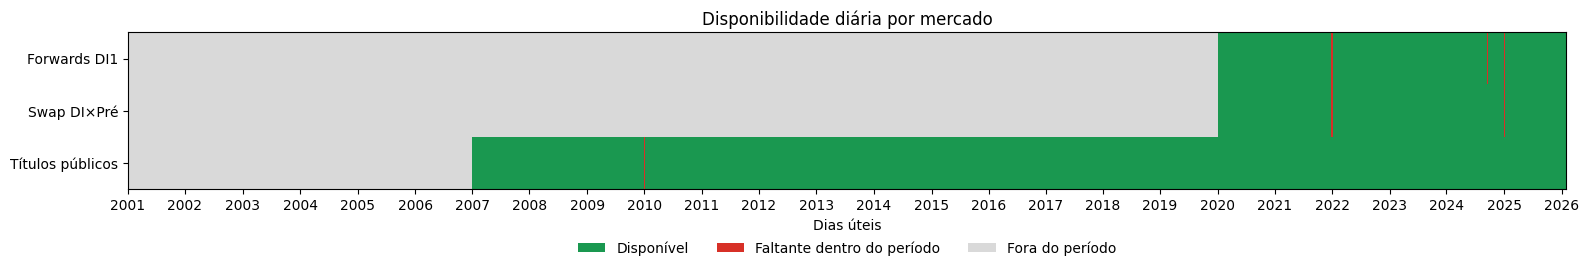

In [99]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def plotar_disponibilidade_mercados(
    calendario,
    forwards,
    swaps,
    bonds,
    calendar_date_col="date",
    ref_date_col="date",
):

    def normalizar_datas(serie):
        # Converte datas timezone-aware e naive para o mesmo padrão diário.
        return pd.to_datetime(serie, errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()

    dias_uteis = (
        calendario.loc[calendario["is_business_day"], [calendar_date_col]]
        .rename(columns={calendar_date_col: "date"})
        .assign(date=lambda df: normalizar_datas(df["date"]))
        .drop_duplicates()
        .sort_values("date")
        .reset_index(drop=True)
    )

    mercados = {
        "Forwards DI1": forwards,
        "Swap DI×Pré": swaps,
        "Títulos públicos": bonds,
    }

    disponibilidade = dias_uteis.copy()

    for nome, df in mercados.items():
        datas_disponiveis = normalizar_datas(df[ref_date_col]).dropna().drop_duplicates()
        inicio, fim = datas_disponiveis.min(), datas_disponiveis.max()

        # -1: fora do período; 0: buraco; 1: observação disponível.
        status = pd.Series(-1, index=disponibilidade.index, dtype="int8")
        dentro_periodo = disponibilidade["date"].between(inicio, fim)
        status.loc[dentro_periodo] = 0
        status.loc[disponibilidade["date"].isin(datas_disponiveis)] = 1
        disponibilidade[nome] = status

    matriz = (
        disponibilidade
        .set_index("date")
        .T
        .astype(int)
    )

    fig, ax = plt.subplots(figsize=(16, 3))

    ax.imshow(
        matriz,
        aspect="auto",
        interpolation="nearest",
        cmap=ListedColormap(["#d9d9d9", "#d73027", "#1a9850"]),
        vmin=-1,
        vmax=1,
    )

    ax.set_yticks(range(len(matriz.index)), labels=matriz.index)

    ticks = disponibilidade.groupby(disponibilidade["date"].dt.year).head(1).index
    ax.set_xticks(
        ticks,
        labels=[matriz.columns[i].strftime("%Y") for i in ticks],
    )

    ax.set_xlabel("Dias úteis")
    ax.set_title("Disponibilidade diária por mercado")
    ax.grid(False)
    ax.legend(
        handles=[
            Patch(facecolor="#1a9850", label="Disponível"),
            Patch(facecolor="#d73027", label="Faltante dentro do período"),
            Patch(facecolor="#d9d9d9", label="Fora do período"),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),
        ncols=3,
        frameon=False,
    )

    plt.tight_layout()
    return disponibilidade, ax

disponibilidade, ax = plotar_disponibilidade_mercados(
    calendario=df_calendar_filtrado,
    forwards=df_fwds_DI,
    swaps=df_swps_DI,
    bonds=df_candidates,
)

plt.show()

### Quantidade de vencimentos disponíveis

In [100]:
from functools import reduce

mercados = {
    "Forwards": df_fwds_DI,
    "Swaps": df_swps_DI,
    "Bonds": df_candidates,
}

# Padronização
painel = pd.concat(
    [
        df.assign(
            mercado=nome,
            date=pd.to_datetime(df["date"]).dt.normalize(),
            tenor_anos=df["bd_to_maturity"] / 252,
        )[["date", "mercado", "bd_to_maturity", "tenor_anos"]]
        for nome, df in mercados.items()
    ],
    ignore_index=True,
)

# Comparação somente nas datas presentes nos três mercados
datas_comuns = reduce(
    set.intersection,
    [set(pd.to_datetime(df["date"]).dt.normalize()) for df in mercados.values()],
)

painel = painel[painel["date"].isin(datas_comuns)].drop_duplicates(
    ["date", "mercado", "bd_to_maturity"]
)

resumo_diario = (
    painel.groupby(["mercado", "date"])
    .agg(
        quantidade_tenors=("bd_to_maturity", "nunique"),
        tenor_minimo=("tenor_anos", "min"),
        tenor_mediano=("tenor_anos", "median"),
        tenor_maximo=("tenor_anos", "max"),
    )
    .reset_index()
)


Os boxplots evidenciam diferenças relevantes na quantidade de vértices observados diariamente. Os títulos públicos apresentam o menor número de vencimentos distintos por data. Esse resultado é coerente com a própria estrutura do mercado: existe um conjunto limitado de títulos em circulação e os vencimentos são determinados pelas emissões do Tesouro, não por uma grade contínua de prazos.

Os futuros de DI ocupam uma posição intermediária. Embora possuam mais vencimentos diários que os títulos públicos, sua cobertura depende dos contratos listados e disponíveis em cada pregão. Os swaps apresentam, com ampla vantagem, a maior quantidade de vértices, chegando a aproximadamente 300 vencimentos em algumas datas.

Essa maior quantidade se deve ao fato dessa já serem taxas referênciais divulgadas pela Bolsa e não as negociações propriamente ditas.

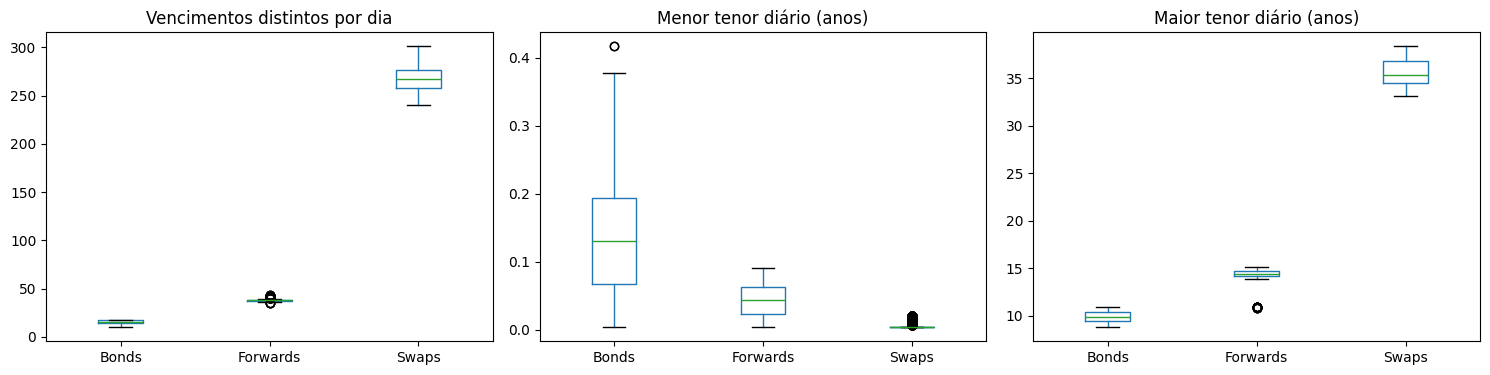

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = {
    "quantidade_tenors": "Vencimentos distintos por dia",
    "tenor_minimo": "Menor tenor diário (anos)",
    "tenor_maximo": "Maior tenor diário (anos)",
}

for ax, (coluna, titulo) in zip(axes, metricas.items()):
    resumo_diario.boxplot(
        column=coluna,
        by="mercado",
        ax=ax,
        grid=False,
    )
    ax.set_title(titulo)
    ax.set_xlabel("")

fig.suptitle("")
plt.tight_layout()

### Amplitude da cobertura de tenors
A análise dos menores e maiores tenors diários reforça a superioridade dos swaps em termos de amplitude. Em média, a base de swaps alcança vencimentos mais curtos e, simultaneamente, vencimentos mais longos. Isso significa que ela cobre de maneira mais completa tanto a região inicial quanto a cauda da curva.

Os títulos públicos apresentam a cobertura mais restrita nos dois extremos. Seu menor tenor diário costuma ser superior ao observado nos outros mercados, indicando menor representação do curtíssimo prazo. Ao mesmo tempo, seu maior tenor diário é, em média, inferior ao dos swaps e futuros, limitando a informação disponível na parte longa da curva.

Esse resultado não deve ser descrito simplesmente como uma “pior qualidade” da base de títulos. Essa característica é diretamente relevante, pois aumenta o risco de instabilidade dos modelos mais flexíveis e torna a extrapolação especialmente sensível às escolhas de regularização e parametrização.

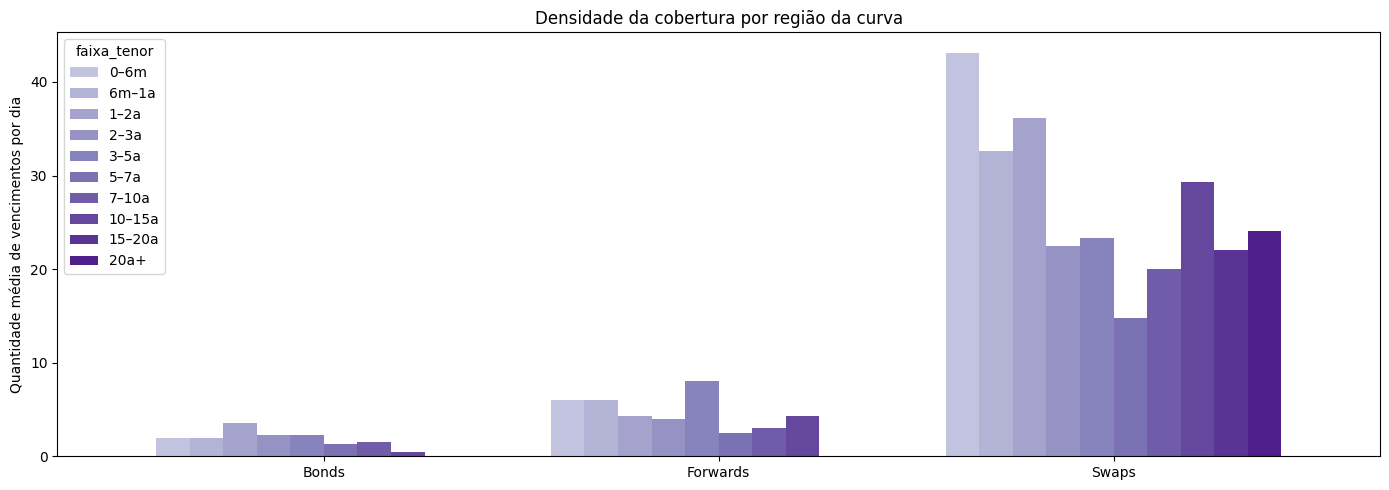

In [102]:
faixas = [0, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, float("inf")]
rotulos = ["0–6m", "6m–1a", "1–2a", "2–3a", "3–5a",
           "5–7a", "7–10a", "10–15a", "15–20a", "20a+"]

painel["faixa_tenor"] = pd.cut(
    painel["tenor_anos"],
    bins=faixas,
    labels=rotulos,
    right=False,
)

densidade = (
    painel.groupby(["mercado", "date", "faixa_tenor"], observed=False)
    .size()
    .groupby(["mercado", "faixa_tenor"], observed=False)
    .mean()
    .unstack(fill_value=0)
)

cores = plt.cm.Purples(
    np.linspace(0.35, 0.90, len(densidade.columns))
)

ax = densidade.plot.bar(
    figsize=(14, 5),
    width=0.85,
    color=cores,
)

ax.set_ylabel("Quantidade média de vencimentos por dia")
ax.set_xlabel("")
ax.set_title("Densidade da cobertura por região da curva")
plt.xticks(rotation=0)
plt.tight_layout()

### Distribuição por regiões da curva
O gráfico de ocupação por faixas de tenor indica uma distribuição relativamente equilibrada para títulos públicos e futuros, enquanto os swaps apresentam maior concentração nos segmentos de curto e médio prazo. Essa concentração sugere que a vantagem dos swaps não está apenas no número total de observações, mas também na maior granularidade em regiões relevantes para a formação das expectativas de juros, como esperado de um arquivo com taxas de referência.

Importante destacar que entre a base de futuros e de títulos, apesar dos dados da DEMAB cobrirem maior horizonte histórico contínuo a quantidade de dados por dia em média é 18 enquanto para a base de futuros temos 38 vencimentos em média, quase 3 vezes mais vértices, logo a base da DEMAB em uma análise transversal diária apresenta cenários mais subindentificados


,mes,dias_disponiveis,dias_qualidade_maxima,primeiro_dia_qualidade_maxima,mes_aprovado
0,2007-01,22,0,NaT,False
1,2007-02,18,0,NaT,False
2,2007-03,22,0,NaT,False
3,2007-04,20,0,NaT,False
4,2007-05,22,0,NaT,False
...,...,...,...,...,...
224,2025-09,22,22,2025-09-01,True
225,2025-10,23,22,2025-10-01,True
226,2025-11,19,19,2025-11-03,True
227,2025-12,22,22,2025-12-01,True


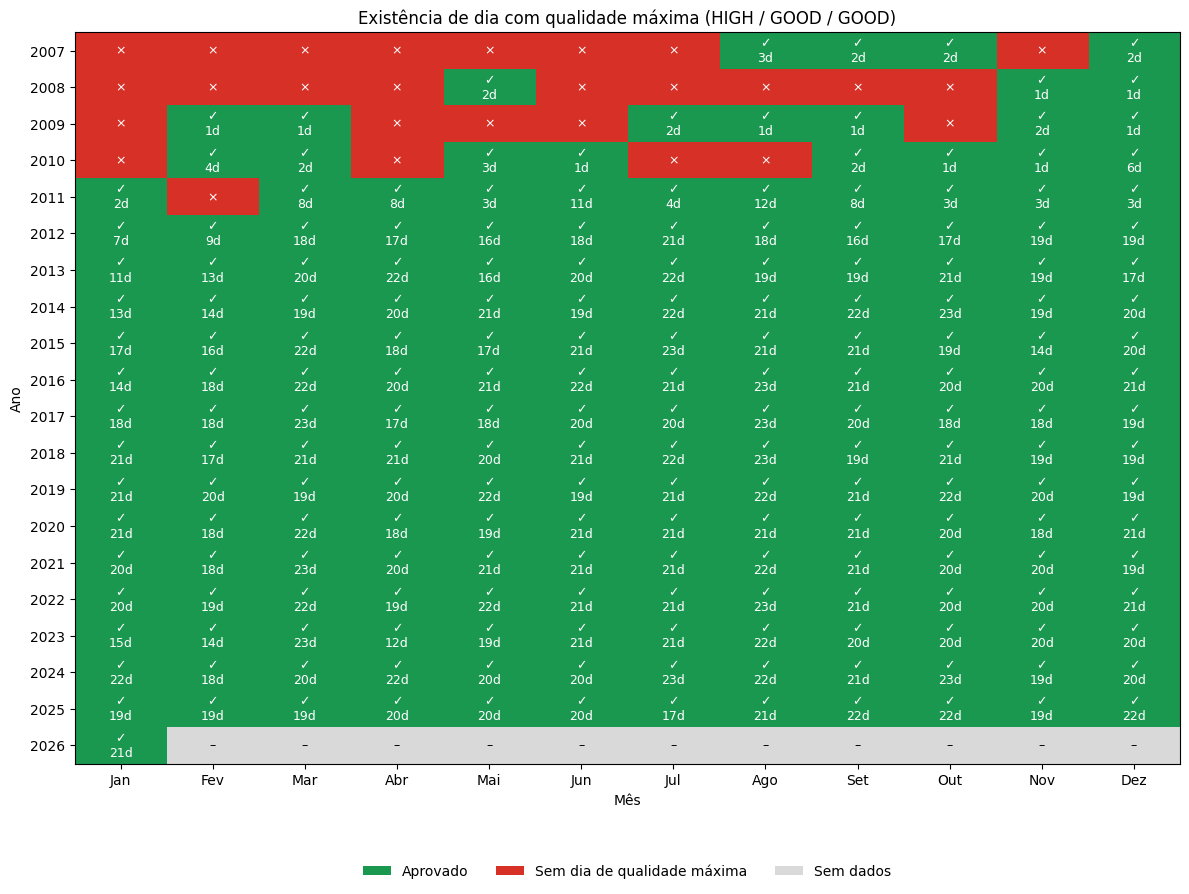

In [103]:
from ml_ettj26.analytics.public_bonds_quality import (
    plotar_qualidade_maxima_mensal,
    verificar_qualidade_maxima_mensal,
)

resumo = verificar_qualidade_maxima_mensal(df_candidates)

todos_os_meses_aprovados = resumo["mes_aprovado"].all()

display(resumo)

plotar_qualidade_maxima_mensal(resumo)
plt.show()

A fim de ilustrar melhor esse fato acrescentei 3 colunas de qualidade no dataframe mart de títulos públicos 

- 1. flag_volume: Mede a quantidade de observações no dia, se < 8 é LOW, se entre 8 e 12 MEDIUM e maior HIGH
- 2. flag_cobertura_tenors: Mede o range maximo coberto pelas observaçõe no dia (MAX_TENOR - MIN_TENOR) / 252 se < que 2 é POOR se entre 2 e 5 MEDIUM e maior que 5 HIGH
- 3. flag_cobertura_tenors: Mede se os períodos de curto, médio e longo prazo estão bem representados e relativamente bem distribuiídos

Esse controle de qualidade é interessante para comparar comportamento em diferentes dias e testar estabilidade em momentos de subindentificação.

No grafico acima podemos ver como os anos de 2007 à 2010 possuem varios meses em que nenhum dia apresenta boa qualidade no mês, acrescentando assim mais uma dificuldade por estar justamente o período da crise financeira global dificultando a idenficação já que a instabilidade será tanto pelo ruído da baixa qualidade dos dados quanto pelo próprio cenário que se desenhava na época

In [109]:
def normalizar_data(serie):
    return (
        pd.to_datetime(serie, errors="coerce", utc=True)
        .dt.tz_convert(None)
        .dt.normalize()
    )


bond_date_col = "date" if "date" in df_candidates.columns else "ref_date"
bond_maturity_col = (
    "maturity"
    if "maturity" in df_candidates.columns
    else "maturity_date"
)

bonds_ltn = df_candidates.loc[
    df_candidates["instrument_type"].eq("LTN")
].copy()

bonds_ltn["date"] = normalizar_data(bonds_ltn[bond_date_col])
bonds_ltn["maturity_bond"] = normalizar_data(
    bonds_ltn[bond_maturity_col]
)
bonds_ltn["yield_bond"] = bonds_ltn["market_ytm"]

bonds_ltn = bonds_ltn[
    [
        "date",
        "bd_to_maturity",
        "maturity_bond",
        "isin",
        "yield_bond",
        "market_pu",
        "quote_quality",
        "flag_volume",
        "flag_cobertura_tenors",
        "flag_ocupacao_tenors",
    ]
].copy()

assert not bonds_ltn.duplicated(
    ["date", "bd_to_maturity"]
).any()


# ------------------------------------------------------------------
# DI futuro — taxas da B3 estão em percentual
# ------------------------------------------------------------------

fwds = df_fwds_DI.copy()
fwds["date"] = normalizar_data(fwds["date"])
fwds["maturity_fwd"] = normalizar_data(fwds["maturity"])
fwds["yield_fwd"] = fwds["adjusted_price"] / 100
fwds["bid_decimal"] = fwds["bid_price"] / 100
fwds["ask_decimal"] = fwds["ask_price"] / 100

fwd_points = (
    fwds.groupby(["date", "bd_to_maturity"], as_index=False)
    .agg(
        maturity_fwd=("maturity_fwd", "min"),
        yield_fwd=("yield_fwd", "median"),
        quantity=(
            "quantity",
            lambda x: x.sum(min_count=1),
        ),
        bid_decimal=("bid_decimal", "median"),
        ask_decimal=("ask_decimal", "median"),
        n_fwd_vertices=("ticker", "nunique"),
    )
)

fwd_points["bid_ask_bps"] = (
    fwd_points["ask_decimal"]
    - fwd_points["bid_decimal"]
) * 10_000


# ------------------------------------------------------------------
# Swap 
# ------------------------------------------------------------------

if "source_bd_to_maturity" not in df_swps_DI.columns:
    raise RuntimeError(
        "Reexecute o pipeline refined_b3_swap_dixpre antes da análise."
    )

swaps = df_swps_DI.copy()
swaps["date"] = normalizar_data(swaps["date"])
swaps["maturity_swap"] = normalizar_data(swaps["maturity"])
swaps["yield_swap"] = swaps["adjusted_value"] / 100
swaps["bd_gap_source"] = (
    swaps["bd_to_maturity"]
    - swaps["source_bd_to_maturity"]
)

swap_points = (
    swaps.groupby(["date", "bd_to_maturity"], as_index=False)
    .agg(
        maturity_swap_min=("maturity_swap", "min"),
        maturity_swap_max=("maturity_swap", "max"),
        yield_swap=("yield_swap", "median"),
        n_swap_vertices=("yield_swap", "size"),
        swap_dispersion_bps=(
            "yield_swap",
            lambda x: (x.max() - x.min()) * 10_000,
        ),
        source_bd_min=("source_bd_to_maturity", "min"),
        source_bd_max=("source_bd_to_maturity", "max"),
        quote_types=(
            "quote_type",
            lambda x: "|".join(
                sorted(set(x.dropna().astype(str)))
            ),
        ),
    )
)

assert not swap_points.duplicated(
    ["date", "bd_to_maturity"]
).any()


# ------------------------------------------------------------------
# Merges
# ------------------------------------------------------------------

df_merged_ltn_fwd = bonds_ltn.merge(
    fwd_points,
    on=["date", "bd_to_maturity"],
    how="inner",
    validate="one_to_one",
)

df_merged_ltn_swap = bonds_ltn.merge(
    swap_points,
    on=["date", "bd_to_maturity"],
    how="inner",
    validate="one_to_one",
)

df_merged_fwd_swap = fwd_points.merge(
    swap_points,
    on=["date", "bd_to_maturity"],
    how="inner",
    validate="one_to_one",
)

df_merged_all = (
    bonds_ltn
    .merge(
        fwd_points,
        on=["date", "bd_to_maturity"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        swap_points,
        on=["date", "bd_to_maturity"],
        how="inner",
        validate="one_to_one",
    )
)


# Spreads em pontos-base

df_merged_ltn_fwd["spread_bps"] = (
    df_merged_ltn_fwd["yield_bond"]
    - df_merged_ltn_fwd["yield_fwd"]
) * 10_000

df_merged_ltn_swap["spread_bps"] = (
    df_merged_ltn_swap["yield_bond"]
    - df_merged_ltn_swap["yield_swap"]
) * 10_000

df_merged_fwd_swap["spread_bps"] = (
    df_merged_fwd_swap["yield_fwd"]
    - df_merged_fwd_swap["yield_swap"]
) * 10_000

df_merged_all["spread_ltn_fwd_bps"] = (
    df_merged_all["yield_bond"]
    - df_merged_all["yield_fwd"]
) * 10_000

df_merged_all["spread_ltn_swap_bps"] = (
    df_merged_all["yield_bond"]
    - df_merged_all["yield_swap"]
) * 10_000

df_merged_all["spread_fwd_swap_bps"] = (
    df_merged_all["yield_fwd"]
    - df_merged_all["yield_swap"]
) * 10_000

### Preparação da análise e definição dos spreads

Nesta etapa, eu construo uma base comparável entre títulos públicos prefixados, futuros de DI e swaps DI x Pré. A restrição da amostra da DEMAB às LTNs é necessária porque esses títulos são zero cupom: seu yield corresponde à taxa que desconta um único fluxo no vencimento. Dessa forma, evito comparar diretamente a yield to maturity de um título com cupons com uma taxa zero de mercado.

As taxas são expressas em uma unidade comum, em formato decimal:

$$
y^{DI}_{t,\tau}=\frac{\text{adjusted\_price}_{t,\tau}}{100},
\qquad
y^{Swap}_{t,\tau}=\frac{\text{adjusted\_value}_{t,\tau}}{100}.
$$

Para cada data $t$ e tenor em dias úteis $\tau$, defino o spread entre os mercados $A$ e $B$, em pontos-base, como:

$$
S^{A-B}_{t,\tau}=10^4\left(y^A_{t,\tau}-y^B_{t,\tau}\right).
$$

O tenor é harmonizado pela chave `date + bd_to_maturity`. Como diferentes datas corridas de swap podem compartilhar o mesmo número de dias úteis, consolido esses registros pela mediana e preservo a amplitude das taxas originais como medida de dispersão. Os `asserts` garantem que cada mercado tenha, ao final, apenas um ponto por data e tenor.

Os merges são internos. Logo, toda a análise subsequente é condicional ao conjunto de vértices efetivamente observados nos dois mercados comparados. Essa escolha assegura comparabilidade, mas introduz seleção amostral: os resultados não representam automaticamente todas as LTNs ou toda a extensão das curvas.

In [110]:
def resumo_cobertura(
    nome,
    base_ltn,
    mercado,
    merged,
):
    inicio = max(
        base_ltn["date"].min(),
        mercado["date"].min(),
    )
    fim = min(
        base_ltn["date"].max(),
        mercado["date"].max(),
    )

    elegiveis = base_ltn.loc[
        base_ltn["date"].between(inicio, fim)
    ]

    matches_dia = merged.groupby("date").size()

    return pd.Series(
        {
            "observacoes": len(merged),
            "dias": merged["date"].nunique(),
            "media_matches_dia": matches_dia.mean(),
            "mediana_matches_dia": matches_dia.median(),
            "cobertura_observacoes_pct": (
                len(merged) / len(elegiveis) * 100
            ),
            "cobertura_dias_pct": (
                merged["date"].nunique()
                / elegiveis["date"].nunique()
                * 100
            ),
        },
        name=nome,
    )


tabela_cobertura = pd.DataFrame(
    [
        resumo_cobertura(
            "LTN × DI",
            bonds_ltn,
            fwd_points,
            df_merged_ltn_fwd,
        ),
        resumo_cobertura(
            "LTN × Swap",
            bonds_ltn,
            swap_points,
            df_merged_ltn_swap,
        ),
    ]
)

tabela_cobertura.round(2)

,observacoes,dias,media_matches_dia,mediana_matches_dia,cobertura_observacoes_pct,cobertura_dias_pct
LTN × DI,6880.0,1507.0,4.57,4.0,41.16,98.63
LTN × Swap,8877.0,1516.0,5.86,6.0,53.11,99.21


### Cobertura temporal e transversal dos merges

O objetivo desta tabela é distinguir continuidade temporal de cobertura transversal. Para cada mercado $M$, calculo:

$$
C^{obs}_M=\frac{N^{match}_M}{N^{LTN,elegivel}_M},
\qquad
C^{dias}_M=\frac{T^{match}_M}{T^{elegivel}_M}.
$$

O merge LTN x DI contém 6.880 observações em 1.507 dias, com média de 4,57 e mediana de 4 vértices por dia. A cobertura temporal é elevada, 98,63%, mas apenas 41,16% das observações elegíveis de LTN encontram um futuro com o mesmo tenor.

O merge LTN x swap contém 8.877 observações em 1.516 dias, com média de 5,86 e mediana de 6 vértices por dia. A cobertura temporal chega a 99,21% e a cobertura transversal a 53,11%. O ganho decorre da grade mais densa da curva de swaps.

Portanto, a amostra é adequada para examinar mudanças ao longo do tempo, mas não cobre uniformemente toda a curva de títulos. O merge com futuros tende a selecionar vencimentos padronizados e mais líquidos, enquanto o swap alcança mais LTNs. Essa diferença de composição deverá ser controlada quando eu comparar os resultados obtidos contra cada referência.

In [111]:
def resumo_spread(df, spread_col="spread_bps"):
    spread = df[spread_col].dropna()
    spread_diario = df.groupby("date")[spread_col].median()

    return pd.Series(
        {
            "observacoes": len(spread),
            "dias": df["date"].nunique(),
            "media_bps": spread.mean(),
            "mediana_bps": spread.median(),
            "desvio_bps": spread.std(),
            "mae_bps": spread.abs().mean(),
            "rmse_bps": np.sqrt(np.mean(spread**2)),
            "p01_bps": spread.quantile(0.01),
            "p05_bps": spread.quantile(0.05),
            "p25_bps": spread.quantile(0.25),
            "p75_bps": spread.quantile(0.75),
            "p95_bps": spread.quantile(0.95),
            "p99_bps": spread.quantile(0.99),
            "abs_ate_5_pct": (
                spread.abs().le(5).mean() * 100
            ),
            "abs_ate_10_pct": (
                spread.abs().le(10).mean() * 100
            ),
            "media_mediana_diaria_bps": (
                spread_diario.mean()
            ),
        }
    )


tabela_spreads = pd.DataFrame(
    {
        "LTN − DI": resumo_spread(
            df_merged_ltn_fwd
        ),
        "LTN − Swap": resumo_spread(
            df_merged_ltn_swap
        ),
        "DI − Swap": resumo_spread(
            df_merged_fwd_swap
        ),
    }
).T

tabela_spreads.round(3)

,observacoes,dias,media_bps,mediana_bps,desvio_bps,mae_bps,rmse_bps,p01_bps,p05_bps,p25_bps,p75_bps,p95_bps,p99_bps,abs_ate_5_pct,abs_ate_10_pct,media_mediana_diaria_bps
LTN − DI,6880.0,1507.0,3.697,2.324,14.388,10.616,14.855,-28.641,-16.668,-4.593,11.006,28.890,43.076,35.538,60.407,5.197
LTN − Swap,8877.0,1516.0,3.566,2.525,13.791,9.973,14.244,-28.463,-15.871,-3.824,10.015,27.048,41.498,38.065,63.760,3.323
DI − Swap,56463.0,1523.0,-0.001,0.000,0.063,0.003,0.063,-0.000,-0.000,0.000,0.000,0.000,0.000,99.998,100.000,0.000


### Nível, dispersão e magnitude econômica dos spreads

Nesta análise, não avalio apenas o viés médio. Para uma amostra com $N$ spreads, utilizo:

$$
\overline{S}=\frac{1}{N}\sum_{i=1}^{N}S_i,
\qquad
MAE=\frac{1}{N}\sum_{i=1}^{N}|S_i|,
\qquad
RMSE=\sqrt{\frac{1}{N}\sum_{i=1}^{N}S_i^2}.
$$

O spread LTN menos DI apresenta média de 3,697 bps e mediana de 2,324 bps. Entretanto, o desvio-padrão é 14,388 bps, o MAE 10,616 bps e o RMSE 14,855 bps. Apenas 35,54% dos pontos ficam dentro de 5 bps e 60,41% dentro de 10 bps. Assim, o basis médio é positivo, mas pequeno diante da dispersão observada.

Para LTN menos swap, a média é 3,566 bps, a mediana 2,525 bps, o MAE 9,973 bps e o RMSE 14,244 bps. A aparente melhora é modesta e pode refletir a maior cobertura transversal do swap, não necessariamente uma taxa economicamente distinta.

Já DI menos swap tem média de -0,001 bp e MAE de apenas 0,003 bp. Praticamente 100% dos pontos estão dentro de 5 bps. Esse resultado antecipa que as duas séries da B3 carregam a mesma informação nos vértices comuns.

A média das medianas diárias é 5,197 bps para LTN menos DI e 3,323 bps para LTN menos swap. A diferença em relação à média por observação demonstra que dias com maior número de matches recebem peso excessivo na estatística convencional. Por isso, a avaliação final dos modelos deverá apresentar métricas balanceadas por dia.

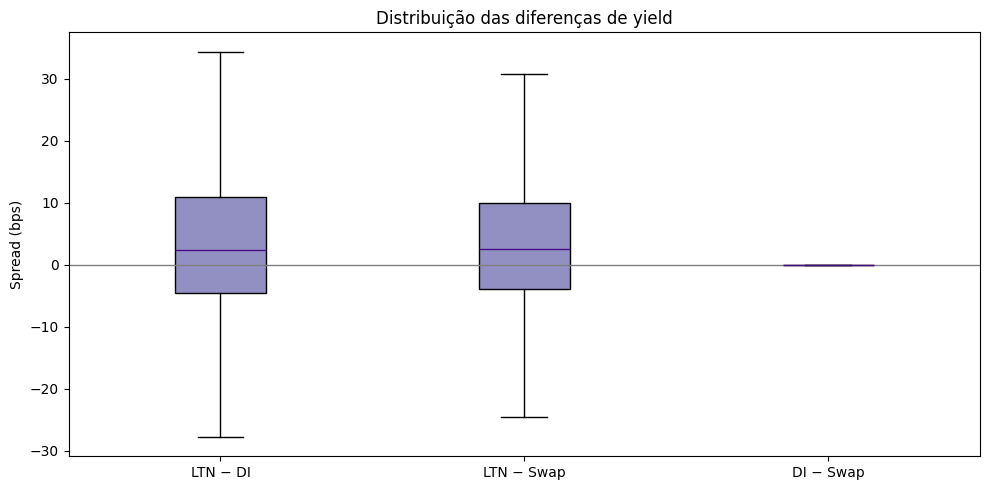

In [112]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(
    [
        df_merged_ltn_fwd["spread_bps"].dropna(),
        df_merged_ltn_swap["spread_bps"].dropna(),
        df_merged_fwd_swap["spread_bps"].dropna(),
    ],
    tick_labels=["LTN − DI", "LTN − Swap", "DI − Swap"],
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": plt.cm.Purples(0.55)},
    medianprops={"color": plt.cm.Purples(0.95)},
)

ax.axhline(0, color="gray", linewidth=1)
ax.set_ylabel("Spread (bps)")
ax.set_title("Distribuição das diferenças de yield")
plt.tight_layout()

### Distribuição central dos spreads

O boxplot resume a mediana, os quartis e o intervalo interquartil de cada spread:

$$
IQR=Q_{0,75}-Q_{0,25}.
$$

As distribuições LTN menos DI e LTN menos swap possuem centro ligeiramente positivo e amplitudes centrais muito semelhantes. A distribuição DI menos swap fica visualmente concentrada sobre zero, reforçando a ausência de diferença econômica entre essas referências nos tenores compartilhados.

Neste gráfico, os outliers foram ocultados por `showfliers=False`. Essa escolha melhora a leitura do centro da distribuição, mas não representa o risco total. Por isso, o boxplot deve ser interpretado em conjunto com os percentis, o RMSE e a análise específica dos maiores desvios.

In [113]:
TENOR_BINS = [
    0, 126, 252, 504, 756, 1260, 1764, np.inf
]

TENOR_LABELS = [
    "0–6m",
    "6m–1a",
    "1–2a",
    "2–3a",
    "3–5a",
    "5–7a",
    "7a+",
]


def adicionar_faixa_tenor(df):
    resultado = df.copy()

    resultado["faixa_tenor"] = pd.cut(
        resultado["bd_to_maturity"],
        bins=TENOR_BINS,
        labels=TENOR_LABELS,
        right=False,
    )

    return resultado


def resumo_por_tenor(df):
    resultado = adicionar_faixa_tenor(df)

    return (
        resultado.groupby(
            "faixa_tenor",
            observed=True,
        )["spread_bps"]
        .agg(
            observacoes="size",
            media_bps="mean",
            mediana_bps="median",
            desvio_bps="std",
            mae_bps=lambda x: x.abs().mean(),
            p05_bps=lambda x: x.quantile(0.05),
            p95_bps=lambda x: x.quantile(0.95),
        )
    )


tenor_ltn_fwd = resumo_por_tenor(
    df_merged_ltn_fwd
)

tenor_ltn_swap = resumo_por_tenor(
    df_merged_ltn_swap
)

display(tenor_ltn_fwd.round(2))
display(tenor_ltn_swap.round(2))

,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps,p05_bps,p95_bps
faixa_tenor,,,,,,,
0–6m,1220,-2.18,-1.10,9.29,7.14,-16.90,11.83
6m–1a,1201,-3.90,-3.61,9.50,7.43,-19.07,8.80
1–2a,2407,3.22,2.83,12.47,9.14,-15.96,22.34
2–3a,1250,9.88,9.78,16.32,14.77,-14.81,35.57
3–5a,693,16.32,16.15,16.94,18.84,-6.91,40.92
5–7a,109,12.48,14.64,15.67,17.34,-19.27,31.59


,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps,p05_bps,p95_bps
faixa_tenor,,,,,,,
0–6m,2082,-0.11,0.56,9.17,6.56,-14.97,12.51
6m–1a,1899,-1.92,-1.36,10.05,7.34,-18.30,12.54
1–2a,2715,3.42,3.01,12.72,9.36,-15.88,23.24
2–3a,1336,9.83,9.82,16.97,14.91,-15.12,35.28
3–5a,734,15.99,15.79,16.98,18.67,-7.43,40.80
5–7a,111,12.34,14.64,15.72,17.27,-19.19,31.55


### Dependência do basis em relação ao prazo

O objetivo desta decomposição é verificar se o spread pode ser tratado como um deslocamento constante ou se varia ao longo da curva. Para cada faixa de tenor $b$, calculo estatísticas condicionais:

$$
\overline{S}_b=E[S_{t,\tau}\mid \tau\in b],
\qquad
Q_{p,b}=Q_p(S_{t,\tau}\mid \tau\in b).
$$

No curto prazo, o spread é negativo ou próximo de zero. Para LTN menos DI, a média é -2,18 bps entre zero e seis meses e -3,90 bps entre seis meses e um ano. A partir de um ano, o sinal se inverte: 3,22 bps entre um e dois anos, 9,88 bps entre dois e três anos e 16,32 bps entre três e cinco anos.

O perfil contra swaps é praticamente o mesmo: -0,11, -1,92, 3,42, 9,83 e 15,99 bps nas mesmas faixas. Entre cinco e sete anos, ambas as referências produzem aproximadamente 12,4 bps, mas com apenas cerca de 110 observações.

A dispersão também aumenta com o prazo, passando de aproximadamente 9 bps no curto para cerca de 17 bps entre três e cinco anos. Portanto, uma métrica global pode compensar erros negativos na ponta curta com erros positivos na região longa. A comparação entre modelos deverá ser estratificada por faixa de tenor. A ausência de resultados em `7a+` indica que não há suporte amostral suficiente para validar essa região diretamente.

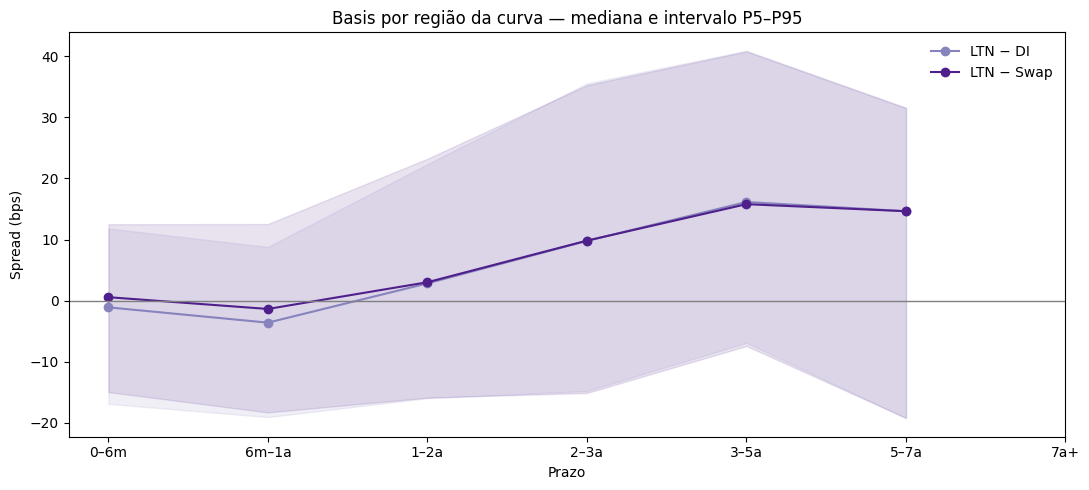

In [114]:
fig, ax = plt.subplots(figsize=(11, 5))

cores = [plt.cm.Purples(0.60), plt.cm.Purples(0.90)]

for nome, resumo, cor in [
    ("LTN − DI", tenor_ltn_fwd, cores[0]),
    ("LTN − Swap", tenor_ltn_swap, cores[1]),
]:
    resumo = resumo.reindex(TENOR_LABELS)
    x = np.arange(len(resumo))

    ax.plot(
        x,
        resumo["mediana_bps"],
        marker="o",
        label=nome,
        color=cor,
    )

    ax.fill_between(
        x,
        resumo["p05_bps"],
        resumo["p95_bps"],
        alpha=0.12,
        color=cor,
    )

ax.axhline(0, color="gray", linewidth=1)
ax.set_xticks(range(len(TENOR_LABELS)), TENOR_LABELS)
ax.set_ylabel("Spread (bps)")
ax.set_xlabel("Prazo")
ax.set_title("Basis por região da curva — mediana e intervalo P5–P95")
ax.legend(frameon=False)
plt.tight_layout()

### Perfil transversal do basis

O gráfico apresenta, para cada faixa, a mediana e o intervalo entre os percentis 5% e 95%. A mediana é utilizada como medida central robusta, enquanto a banda representa a dispersão empírica:

$$
\widetilde{S}_b=Q_{0,50}(S\mid b),
\qquad
I_b=[Q_{0,05}(S\mid b),Q_{0,95}(S\mid b)].
$$

As duas linhas são quase coincidentes depois de um ano, confirmando que DI e swap produzem essencialmente a mesma referência nesses vértices. O basis possui inclinação positiva até a faixa de três a cinco anos. Apesar dessa regularidade, as bandas são amplas e atravessam zero em quase todas as regiões, demonstrando que a relação não é determinística e pode mudar de sinal em datas específicas.

Para o teste cross-market, o formato da curva do erro é mais informativo que sua média. Um modelo que reproduza corretamente o nível geral, mas gere uma inclinação artificial do spread, deverá ser penalizado mesmo que seu erro médio agregado seja baixo.

In [115]:
def resumo_anual(df):
    return (
        df.groupby(df["date"].dt.year)["spread_bps"]
        .agg(
            observacoes="size",
            media_bps="mean",
            mediana_bps="median",
            desvio_bps="std",
            mae_bps=lambda x: x.abs().mean(),
            p05_bps=lambda x: x.quantile(0.05),
            p95_bps=lambda x: x.quantile(0.95),
        )
    )


anual_ltn_fwd = resumo_anual(df_merged_ltn_fwd)
anual_ltn_swap = resumo_anual(df_merged_ltn_swap)

display(anual_ltn_fwd.round(2))
display(anual_ltn_swap.round(2))

,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps,p05_bps,p95_bps
date,,,,,,,
2020,724,6.36,3.66,15.22,9.46,-7.39,28.03
2021,566,12.20,9.71,15.72,15.17,-8.28,39.46
2022,893,8.85,7.90,17.35,14.72,-18.86,37.76
2023,1478,6.56,5.26,12.68,10.91,-12.69,28.87
2024,1654,-2.36,-2.12,12.25,9.24,-21.90,16.17
2025,1460,0.19,-0.87,11.44,8.37,-15.54,21.06
2026,105,-0.41,-2.71,9.91,7.87,-12.16,19.29


,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps,p05_bps,p95_bps
date,,,,,,,
2020,984,6.60,4.86,15.20,9.51,-5.98,28.04
2021,1319,7.22,6.08,14.29,11.42,-10.78,33.07
2022,1419,6.48,4.71,14.96,11.59,-14.91,33.02
2023,1791,5.65,3.77,12.43,10.01,-12.49,27.22
2024,1705,-2.46,-2.26,12.29,9.29,-21.91,16.24
2025,1547,0.35,-0.72,11.46,8.42,-15.51,21.21
2026,112,-0.11,-2.56,10.07,7.91,-12.14,21.43


### Variação anual e mudanças de regime

Nesta etapa, avalio se a relação entre os mercados permanece estável ao longo do tempo. Para cada ano $a$, calculo a média condicional:

$$
\overline{S}_a=\frac{1}{N_a}\sum_{i:\,ano(t_i)=a}S_i.
$$

Entre 2020 e 2023, o basis é predominantemente positivo. O spread LTN menos DI atinge média de 12,20 bps em 2021 e 8,85 bps em 2022, enquanto LTN menos swap apresenta 7,22 e 6,48 bps. Esses anos também exibem MAE e dispersão elevados, compatíveis com um período de forte reprecificação monetária e maior instabilidade da curva.

Em 2024, ocorre uma inversão: as médias passam para -2,36 bps contra DI e -2,46 bps contra swap. Em 2025 e no início de 2026, os spreads médios se aproximam de zero. Logo, o basis apresenta mudança de regime e não pode ser tratado como uma constante estrutural no período inteiro.

A diferença entre as médias LTN menos DI e LTN menos swap em 2021-2023 deve ser interpretada com cautela, pois os merges contêm conjuntos distintos de LTNs. Quando a amostra é igualada, essa diferença praticamente desaparece. Para comparar modelos, reportarei métricas por ano ou regime, evitando que períodos de sinais opostos se anulem na média total.

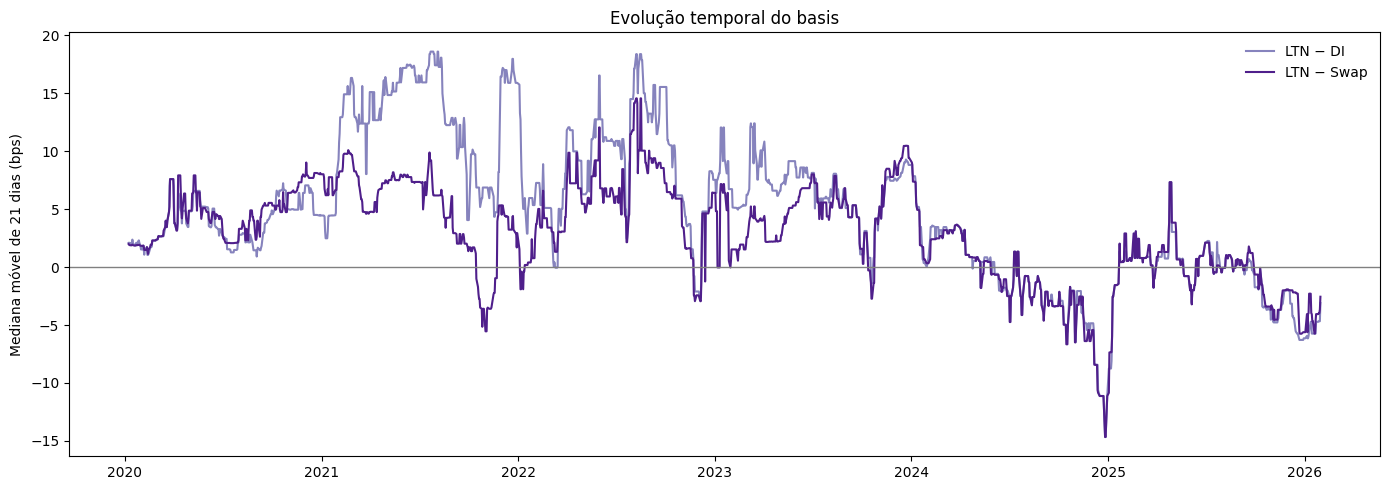

In [116]:
fig, ax = plt.subplots(figsize=(14, 5))

for nome, df, cor in [
    ("LTN − DI", df_merged_ltn_fwd, plt.cm.Purples(0.60)),
    ("LTN − Swap", df_merged_ltn_swap, plt.cm.Purples(0.90)),
]:
    spread_diario = (
        df.groupby("date")["spread_bps"]
        .median()
        .sort_index()
    )

    media_21d = spread_diario.rolling(
        21,
        min_periods=5,
    ).median()

    ax.plot(
        media_21d.index,
        media_21d,
        label=nome,
        color=cor,
    )

ax.axhline(0, color="gray", linewidth=1)
ax.set_ylabel("Mediana móvel de 21 dias (bps)")
ax.set_title("Evolução temporal do basis")
ax.legend(frameon=False)
plt.tight_layout()

### Persistência temporal do basis

Para reduzir o ruído diário e destacar movimentos persistentes, calculo a mediana móvel de 21 pregões:

$$
\widetilde{S}^{(21)}_t=
\operatorname{mediana}\left(\widetilde{S}_{t-20},\ldots,\widetilde{S}_t\right),
$$

em que $\widetilde{S}_t$ é a mediana cross-sectional dos spreads observados no dia $t$. A janela de 21 dias representa aproximadamente um mês de negociação e reduz a influência de observações isoladas.

A série LTN menos DI alcança aproximadamente 18,6 bps em julho de 2021, enquanto LTN menos swap chega a cerca de 14,6 bps em agosto de 2022. Ambas atingem aproximadamente -14,7 bps em dezembro de 2024. A mudança de sinal não é pontual: ela persiste por várias janelas, reforçando a existência de regimes distintos.

As linhas se aproximam fortemente a partir de 2024. Nos anos anteriores, parte da distância entre elas decorre da cobertura adicional do swap. Para o teste dos modelos, essa dinâmica exige avaliar estabilidade temporal do erro, e não apenas aderência média in-sample.

In [117]:
fwd_exact = fwds[
    [
        "date",
        "maturity_fwd",
        "bd_to_maturity",
        "yield_fwd",
    ]
].rename(
    columns={"bd_to_maturity": "bd_fwd"}
)

swap_exact = swaps[
    [
        "date",
        "maturity_swap",
        "bd_to_maturity",
        "yield_swap",
    ]
].rename(
    columns={"bd_to_maturity": "bd_swap"}
)

df_exact_fwd_swap = fwd_exact.merge(
    swap_exact,
    left_on=["date", "maturity_fwd"],
    right_on=["date", "maturity_swap"],
    how="inner",
)

df_exact_fwd_swap["spread_bps"] = (
    df_exact_fwd_swap["yield_fwd"]
    - df_exact_fwd_swap["yield_swap"]
) * 10_000

df_exact_fwd_swap["bd_gap"] = (
    df_exact_fwd_swap["bd_fwd"]
    - df_exact_fwd_swap["bd_swap"]
)

resumo_redundancia = pd.Series(
    {
        "matches_exatos": len(df_exact_fwd_swap),
        "percentual_dos_futuros": (
            len(df_exact_fwd_swap) / len(fwds) * 100
        ),
        "media_spread_bps": (
            df_exact_fwd_swap["spread_bps"].mean()
        ),
        "mae_bps": (
            df_exact_fwd_swap["spread_bps"].abs().mean()
        ),
        "max_abs_bps": (
            df_exact_fwd_swap["spread_bps"].abs().max()
        ),
        "bd_gap_nao_zero": (
            df_exact_fwd_swap["bd_gap"].ne(0).sum()
        ),
    }
)

resumo_redundancia

matches_exatos            5.646200e+04
percentual_dos_futuros    9.674611e+01
media_spread_bps         -5.892812e-16
mae_bps                   3.328671e-14
max_abs_bps               2.775558e-13
bd_gap_nao_zero           0.000000e+00
dtype: float64

### Redundância informacional entre futuros de DI e swaps

O objetivo deste teste é verificar se DI e swap constituem referências cross-market independentes. Para isso, imponho a condição mais restritiva possível: mesma data e mesma maturity. Em cada match exato, calculo:

$$
S^{DI-Swap}_{t,m}=10^4\left(y^{DI}_{t,m}-y^{Swap}_{t,m}\right).
$$

Foram encontrados 56.462 matches, equivalentes a 96,75% das observações de futuros. O spread médio, o MAE e o maior valor absoluto são numericamente zero, e não existe qualquer divergência de `bd_to_maturity` após a harmonização do calendário.

Esse resultado é mais forte que uma correlação elevada: ele demonstra identidade numérica nos vértices comuns. Portanto, DI e swap não devem ser contabilizados como dois benchmarks independentes. O swap acrescenta densidade entre os vencimentos dos futuros, mas, nos vencimentos coincidentes, reproduz a mesma informação de mercado.

In [118]:
tabela_amostra_comum = pd.DataFrame(
    {
        "LTN − DI": resumo_spread(
            df_merged_all,
            "spread_ltn_fwd_bps",
        ),
        "LTN − Swap": resumo_spread(
            df_merged_all,
            "spread_ltn_swap_bps",
        ),
        "DI − Swap": resumo_spread(
            df_merged_all,
            "spread_fwd_swap_bps",
        ),
    }
).T

tabela_amostra_comum.round(4)

,observacoes,dias,media_bps,mediana_bps,desvio_bps,mae_bps,rmse_bps,p01_bps,p05_bps,p25_bps,p75_bps,p95_bps,p99_bps,abs_ate_5_pct,abs_ate_10_pct,media_mediana_diaria_bps
LTN − DI,6745.0,1500.0,3.6909,2.3311,14.3984,10.6174,14.8629,-28.6919,-16.6673,-4.6092,11.0146,28.8833,43.1653,35.5374,60.4596,5.2141
LTN − Swap,6745.0,1500.0,3.6887,2.3250,14.3980,10.6160,14.8619,-28.6919,-16.6673,-4.6092,11.0060,28.8833,43.1653,35.5523,60.4744,5.2130
DI − Swap,6745.0,1500.0,-0.0022,0.0000,0.0418,0.0023,0.0419,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,-0.0000


### Comparação sobre uma amostra comum

Para eliminar o efeito de composição, restrinjo a análise ao conjunto comum:

$$
\Omega=\Omega_{LTN}\cap\Omega_{DI}\cap\Omega_{Swap},
$$

em que cada elemento de $\Omega$ é uma combinação de data e tenor. A amostra resultante contém 6.745 observações em 1.500 dias.

Sobre essa mesma amostra, LTN menos DI apresenta média de 3,6909 bps, mediana de 2,3311 bps, MAE de 10,6174 bps e RMSE de 14,8629 bps. LTN menos swap apresenta, respectivamente, 3,6887, 2,3250, 10,6160 e 14,8619 bps. As diferenças são economicamente irrelevantes.

O spread DI menos swap tem média de -0,0022 bp e MAE de 0,0023 bp. Assim, as diferenças observadas nos merges dois a dois decorrem da composição dos vértices disponíveis, não de uma divergência substantiva entre as duas referências da B3.

Essa amostra comum é a base mais justa para comparar simultaneamente os modelos contra DI e swap. Ainda assim, os dois resultados deverão ser interpretados como verificações da mesma família de referência, e não como duas evidências independentes.

In [119]:
def resumo_correlacao(
    df,
    yield_a,
    yield_b,
):
    diario = (
        df.groupby("date")[[yield_a, yield_b]]
        .median()
        .sort_index()
    )

    return pd.Series(
        {
            "correlacao_niveis": (
                diario[yield_a].corr(diario[yield_b])
            ),
            "correlacao_variacoes": (
                diario[yield_a]
                .diff()
                .corr(diario[yield_b].diff())
            ),
        }
    )


tabela_correlacoes = pd.DataFrame(
    {
        "LTN × DI": resumo_correlacao(
            df_merged_ltn_fwd,
            "yield_bond",
            "yield_fwd",
        ),
        "LTN × Swap": resumo_correlacao(
            df_merged_ltn_swap,
            "yield_bond",
            "yield_swap",
        ),
        "DI × Swap": resumo_correlacao(
            df_merged_fwd_swap,
            "yield_fwd",
            "yield_swap",
        ),
    }
).T

tabela_correlacoes.round(4)

,correlacao_niveis,correlacao_variacoes
LTN × DI,0.9994,0.9522
LTN × Swap,0.9996,0.9575
DI × Swap,1.0000,1.0000


### Correlação das curvas agregadas

Nesta análise, agrego cada mercado pela mediana diária e calculo a correlação de Pearson nos níveis e nas primeiras diferenças. Para duas séries $x_t$ e $y_t$:

$$
\rho(x,y)=\frac{\operatorname{Cov}(x,y)}{\sigma_x\sigma_y},
\qquad
\Delta x_t=x_t-x_{t-1}.
$$

A correlação de níveis é 0,9994 para LTN x DI e 0,9996 para LTN x swap. Nas variações diárias, permanece elevada: 0,9522 e 0,9575. DI x swap apresenta correlação igual a 1 tanto nos níveis quanto nas variações.

Esses resultados mostram que os mercados compartilham o mesmo fator agregado de juros. Contudo, a mediana diária pode mudar tanto por movimento da curva quanto por alteração na composição dos tenores observados. Portanto, uma correlação agregada próxima de um não comprova que cada título esteja sendo marcado de maneira consistente com seu vértice correspondente. Essa distinção é investigada na análise seguinte.

In [120]:
calendar_index = df_calendar.copy()
calendar_index["date"] = normalizar_data(
    calendar_index["date"]
)

calendar_index = calendar_index[
    ["date", "bd_index"]
].drop_duplicates("date")


def correlacao_por_instrumento(df, market_yield_col):
    resultado = (
        df.merge(
            calendar_index,
            on="date",
            how="left",
            validate="many_to_one",
        )
        .sort_values(["isin", "date"])
        .copy()
    )

    resultado["gap_bd"] = (
        resultado.groupby("isin")["bd_index"].diff()
    )

    resultado["delta_bond"] = (
        resultado.groupby("isin")["yield_bond"].diff()
    )

    resultado["delta_market"] = (
        resultado.groupby("isin")[market_yield_col].diff()
    )

    consecutivos = resultado["gap_bd"].eq(1)

    return pd.Series(
        {
            "observacoes": consecutivos.sum(),
            "correlacao_variacoes": (
                resultado.loc[
                    consecutivos,
                    "delta_bond",
                ].corr(
                    resultado.loc[
                        consecutivos,
                        "delta_market",
                    ]
                )
            ),
        }
    )


pd.DataFrame(
    {
        "LTN × DI": correlacao_por_instrumento(
            df_merged_ltn_fwd,
            "yield_fwd",
        ),
        "LTN × Swap": correlacao_por_instrumento(
            df_merged_ltn_swap,
            "yield_swap",
        ),
    }
).T.round(4)

,observacoes,correlacao_variacoes
LTN × DI,3857.0,0.1290
LTN × Swap,5839.0,0.1105


### Correlação das variações por instrumento

Para remover o efeito de mudanças na composição da amostra, acompanho cada ISIN em dias úteis consecutivos. Para o instrumento $i$:

$$
\Delta y^{LTN}_{i,t}=y^{LTN}_{i,t}-y^{LTN}_{i,t-1},
\qquad
\Delta y^{M}_{i,t}=y^{M}_{t,\tau_{i,t}}-y^{M}_{t-1,\tau_{i,t-1}}.
$$

A correlação das variações cai para 0,1290 entre LTN e DI, com 3.857 observações consecutivas, e para 0,1105 entre LTN e swap, com 5.839 observações. A diferença em relação às correlações agregadas superiores a 0,95 é substancial.

Isso indica que o fator comum de nível domina o movimento das curvas, mas a marcação diária de cada LTN contém forte componente idiossincrático. Entre as possíveis fontes estão diferenças de horário e metodologia de formação, PU médio da DEMAB versus taxa de ajuste da B3, liquidez, arredondamento, basis variável e ruído próximo ao vencimento.

Para avaliar previsões diárias ou estabilidade out-of-sample, esta medida por instrumento é mais informativa que a correlação de níveis. Um modelo pode acompanhar o ciclo agregado de juros e ainda assim falhar na dinâmica local dos vértices.

In [121]:
def media_ponderada_dentro_do_dia(
    df,
    spread_col,
    peso,
):
    resultado = df.copy()
    resultado["_peso"] = pd.Series(
        peso,
        index=resultado.index,
    ).fillna(0).clip(lower=0)

    soma_peso = resultado.groupby("date")[
        "_peso"
    ].transform("sum")

    validos = soma_peso.gt(0)

    resultado.loc[validos, "_peso_normalizado"] = (
        resultado.loc[validos, "_peso"]
        / soma_peso.loc[validos]
    )

    resultado["_spread_ponderado"] = (
        resultado[spread_col]
        * resultado["_peso_normalizado"]
    )

    return (
        resultado.loc[validos]
        .groupby("date")["_spread_ponderado"]
        .sum()
        .mean()
    )


analise_pesos = adicionar_faixa_tenor(
    df_merged_ltn_fwd
)

media_por_dia = (
    analise_pesos.groupby("date")["spread_bps"]
    .mean()
    .mean()
)

mediana_por_dia = (
    analise_pesos.groupby("date")["spread_bps"]
    .median()
    .mean()
)

media_dia_faixa = (
    analise_pesos
    .groupby(
        ["date", "faixa_tenor"],
        observed=True,
    )["spread_bps"]
    .mean()
    .groupby("date")
    .mean()
    .mean()
)

quantidade = analise_pesos["quantity"].fillna(0)

peso_quantidade_bruta = np.average(
    analise_pesos.loc[
        quantidade.gt(0),
        "spread_bps",
    ],
    weights=quantidade.loc[quantidade.gt(0)],
)

peso_log_quantidade = media_ponderada_dentro_do_dia(
    analise_pesos,
    spread_col="spread_bps",
    peso=np.log1p(quantidade),
)

mediana_bid_ask = analise_pesos[
    "bid_ask_bps"
].median()

amostra_bid_ask_estreito = analise_pesos.loc[
    analise_pesos["bid_ask_bps"].le(mediana_bid_ask)
]

tabela_ponderacoes = pd.Series(
    {
        "Observações iguais": (
            analise_pesos["spread_bps"].mean()
        ),
        "Dias iguais": media_por_dia,
        "Mediana diária": mediana_por_dia,
        "Dia e faixa iguais": media_dia_faixa,
        "Quantidade bruta": peso_quantidade_bruta,
        "log1p(quantity), normalizado por dia": (
            peso_log_quantidade
        ),
        "Bid-ask abaixo da mediana": (
            amostra_bid_ask_estreito[
                "spread_bps"
            ].mean()
        ),
    },
    name="basis_medio_bps",
)

tabela_ponderacoes.round(3)

Observações iguais                      3.697
Dias iguais                             5.294
Mediana diária                          5.197
Dia e faixa iguais                      5.586
Quantidade bruta                        2.241
log1p(quantity), normalizado por dia    5.294
Bid-ask abaixo da mediana               1.694
Name: basis_medio_bps, dtype: float64

### Sensibilidade dos resultados às ponderações

O objetivo desta etapa é verificar se o basis estimado depende da distribuição de observações, dias, prazos e liquidez. A média convencional atribui peso idêntico a cada ponto:

$$
\widehat{\mu}_{obs}=\frac{1}{N}\sum_{t,\tau}S_{t,\tau}.
$$

Para atribuir o mesmo peso a cada dia, calculo primeiro a média cross-sectional e depois a média temporal. Na ponderação por dia e faixa, cada região disponível da curva recebe peso igual dentro de cada data. Para a ponderação de liquidez, utilizo:

$$
w_{t,\tau}=\frac{\log(1+q_{t,\tau})}
{\sum_j\log(1+q_{t,j})},
\qquad
\widehat{\mu}_{liq}=\frac{1}{T}\sum_t\sum_\tau w_{t,\tau}S_{t,\tau}.
$$

A média por observação é 3,697 bps, enquanto pesos iguais por dia produzem 5,294 bps e a mediana diária 5,197 bps. Ao balancear simultaneamente dia e faixa de tenor, o resultado sobe para 5,586 bps. Isso indica que dias e regiões com menos observações possuem, em média, basis mais positivo.

A ponderação por quantidade bruta reduz o resultado para 2,241 bps, mostrando que os contratos mais negociados estão associados a spreads menores ou se concentram em regiões da curva com menor basis. O corte de bid-ask abaixo da mediana reduz a média para 1,694 bps, sugerindo associação entre liquidez e alinhamento. Contudo, esse filtro também altera a composição por prazo e período, de modo que não atribuo causalidade exclusivamente à liquidez.

No teste dos modelos, utilizarei como métrica principal o balanceamento por dia e faixa. Quantidade e bid-ask serão tratados como análises de robustez, pois pesos de volume bruto podem concentrar excessivamente o resultado em poucos contratos.

In [122]:
def resumo_por_flag(df, flag_col):
    return (
        df.groupby(flag_col)["spread_bps"]
        .agg(
            observacoes="size",
            media_bps="mean",
            mediana_bps="median",
            desvio_bps="std",
            mae_bps=lambda x: x.abs().mean(),
        )
        .round(2)
    )


for flag in [
    "flag_volume",
    "flag_cobertura_tenors",
    "flag_ocupacao_tenors",
]:
    print(f"\n{flag}")
    display(
        resumo_por_flag(
            df_merged_ltn_fwd,
            flag,
        )
    )


flag_volume


,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps
flag_volume,,,,,
HIGH,6877,3.70,2.32,14.39,10.62
MEDIUM,3,6.06,7.31,2.64,6.06



flag_cobertura_tenors


,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps
flag_cobertura_tenors,,,,,
GOOD,6880,3.7,2.32,14.39,10.62



flag_ocupacao_tenors


,observacoes,media_bps,mediana_bps,desvio_bps,mae_bps
flag_ocupacao_tenors,,,,,
GOOD,6676,3.57,2.30,14.39,10.61
MEDIUM,204,7.72,3.06,13.90,10.93


### Poder discriminante das flags de qualidade

Nesta análise, verifico se as flags construídas para volume, cobertura e ocupação também explicam as divergências cross-market. Para cada categoria $g$, avalio:

$$
\overline{S}_g=E[S\mid G=g],
\qquad
MAE_g=E[|S|\mid G=g].
$$

A amostra cross-market já está fortemente selecionada: 6.877 das 6.880 observações LTN x DI pertencem a dias de volume `HIGH`, e todas possuem cobertura `GOOD`. Essas flags, portanto, não oferecem variação suficiente para explicar os spreads nesta subamostra.

Na ocupação, a categoria `MEDIUM` apresenta média de 7,72 bps contra 3,57 bps para `GOOD`, mas contém apenas 204 observações. As medianas são próximas, 3,06 e 2,30 bps, e os MAEs também são semelhantes, 10,93 e 10,61 bps. A diferença da média parece decorrer de assimetria ou de poucos valores positivos elevados.

Concluo que as flags são úteis para selecionar dias adequados à calibração, mas não substituem uma métrica própria de consistência cross-market. Depois do merge, a amostra já se concentra nos dias de melhor qualidade transversal.

In [123]:
def adicionar_flag_crossmarket(df):
    resultado = df.copy()

    resultado["flag_crossmarket"] = pd.cut(
        resultado["spread_bps"].abs(),
        bins=[0, 10, 25, 50, np.inf],
        labels=[
            "ALIGNED",
            "MODERATE",
            "HIGH",
            "EXTREME",
        ],
        include_lowest=True,
    )

    return resultado


df_merged_ltn_fwd = adicionar_flag_crossmarket(
    df_merged_ltn_fwd
)

df_merged_ltn_swap = adicionar_flag_crossmarket(
    df_merged_ltn_swap
)

df_merged_ltn_fwd[
    "flag_crossmarket"
].value_counts(normalize=True).mul(100).round(2)

flag_crossmarket
ALIGNED     60.41
MODERATE    30.71
HIGH         8.37
EXTREME      0.51
Name: proportion, dtype: float64

### Classificação descritiva do desalinhamento cross-market

Para facilitar a inspeção dos spreads, classifico a magnitude absoluta em quatro faixas:

$$
G(S)=
\begin{cases}
\text{ALIGNED}, & |S|\leq 10,\\
\text{MODERATE}, & 10<|S|\leq 25,\\
\text{HIGH}, & 25<|S|\leq 50,\\
\text{EXTREME}, & |S|>50.
\end{cases}
$$

Apenas 60,41% dos matches LTN x DI estão dentro de 10 bps. Outros 30,71% ficam entre 10 e 25 bps, 8,37% entre 25 e 50 bps e 0,51% acima de 50 bps. Assim, quase 40% da amostra apresenta diferença superior a 10 bps.

Esses limites são critérios descritivos, não testes estatísticos nem regras automáticas de exclusão. Uma observação `HIGH` ou `EXTREME` pode representar erro, diferença de horário, microestrutura ou um episódio econômico legítimo. A flag será utilizada para segmentar a avaliação e localizar períodos críticos, preservando os dados para diagnóstico.

In [124]:
def maiores_outliers(
    df,
    n=20,
):
    resultado = df.copy()
    resultado["abs_spread_bps"] = (
        resultado["spread_bps"].abs()
    )

    colunas = [
        "date",
        "isin",
        "maturity_bond",
        "bd_to_maturity",
        "yield_bond",
        "spread_bps",
        "abs_spread_bps",
        "market_pu",
        "flag_volume",
        "flag_cobertura_tenors",
        "flag_ocupacao_tenors",
    ]

    colunas_mercado = [
        coluna
        for coluna in [
            "yield_fwd",
            "yield_swap",
            "quantity",
            "bid_ask_bps",
            "swap_dispersion_bps",
        ]
        if coluna in resultado.columns
    ]

    return (
        resultado.nlargest(n, "abs_spread_bps")[
            colunas + colunas_mercado
        ]
    )


outliers_ltn_fwd = maiores_outliers(
    df_merged_ltn_fwd
)

outliers_ltn_swap = maiores_outliers(
    df_merged_ltn_swap
)

display(outliers_ltn_fwd)
display(outliers_ltn_swap)

,date,isin,maturity_bond,bd_to_maturity,yield_bond,spread_bps,abs_spread_bps,market_pu,flag_volume,flag_cobertura_tenors,flag_ocupacao_tenors,yield_fwd,quantity,bid_ask_bps
306,2020-04-24,BRSTNCLTN7S1,2024-01-01,925,0.054427,-137.725998,137.725998,823.216677,HIGH,GOOD,GOOD,0.06820,7490.0,20.0
5291,2024-12-20,BRSTNCLTN8A7,2030-01-01,1256,0.156286,122.662408,122.662408,484.924636,HIGH,GOOD,GOOD,0.14402,34107.0,4.0
208,2020-03-16,BRSTNCLTN004,2020-10-01,138,0.047200,105.000006,105.000006,975.060113,HIGH,GOOD,GOOD,0.03670,3232.0,3.0
205,2020-03-13,BRSTNCLTN7S1,2024-01-01,953,0.077716,104.156526,104.156526,753.489850,HIGH,GOOD,GOOD,0.06730,8948.0,NaN
2045,2022-11-10,BRSTNCLTN7Z6,2025-07-01,660,0.120161,-97.386374,97.386374,742.902452,HIGH,GOOD,GOOD,0.12990,28299.0,4.0
238,2020-03-25,BRSTNCLTN7I2,2021-07-01,317,0.047022,89.217378,89.217378,943.837000,HIGH,GOOD,GOOD,0.03810,4460.0,8.0
200,2020-03-12,BRSTNCLTN7I2,2021-07-01,326,0.047710,-87.898760,87.898760,941.488528,HIGH,GOOD,GOOD,0.05650,2931.0,7.0
203,2020-03-13,BRSTNCLTN7T9,2022-04-01,515,0.064110,86.100004,86.100004,880.742528,HIGH,GOOD,GOOD,0.05550,517.0,NaN
204,2020-03-13,BRSTNCLTN7O0,2022-07-01,577,0.066551,85.511538,85.511538,862.841079,HIGH,GOOD,GOOD,0.05800,6982.0,NaN
201,2020-03-13,BRSTNCLTN7P7,2021-04-01,263,0.052875,76.754321,76.754321,947.646220,HIGH,GOOD,GOOD,0.04520,3965.0,NaN


,date,isin,maturity_bond,bd_to_maturity,yield_bond,spread_bps,abs_spread_bps,market_pu,flag_volume,flag_cobertura_tenors,flag_ocupacao_tenors,yield_swap,swap_dispersion_bps
215,2020-03-12,BRSTNCLTN7O0,2022-07-01,577,0.050252,-173.081296,173.081296,893.635124,HIGH,GOOD,GOOD,0.067560,0.0
338,2020-04-24,BRSTNCLTN7S1,2024-01-01,925,0.054427,-137.725998,137.725998,823.216677,HIGH,GOOD,GOOD,0.068200,0.0
7193,2024-12-20,BRSTNCLTN8A7,2030-01-01,1256,0.156286,122.662408,122.662408,484.924636,HIGH,GOOD,GOOD,0.144020,0.0
224,2020-03-16,BRSTNCLTN004,2020-10-01,138,0.047200,105.000006,105.000006,975.060113,HIGH,GOOD,GOOD,0.036700,0.0
221,2020-03-13,BRSTNCLTN7S1,2024-01-01,953,0.077716,104.156526,104.156526,753.489850,HIGH,GOOD,GOOD,0.067300,0.0
5076,2023-09-27,BRSTNCLTN814,2023-10-01,2,0.136714,102.340206,102.340206,998.475667,HIGH,GOOD,GOOD,0.126480,0.0
3537,2022-11-10,BRSTNCLTN7Z6,2025-07-01,660,0.120161,-97.386374,97.386374,742.902452,HIGH,GOOD,GOOD,0.129900,0.0
255,2020-03-25,BRSTNCLTN7I2,2021-07-01,317,0.047022,89.217378,89.217378,943.837000,HIGH,GOOD,GOOD,0.038100,0.0
214,2020-03-12,BRSTNCLTN7I2,2021-07-01,326,0.047710,-87.898760,87.898760,941.488528,HIGH,GOOD,GOOD,0.056500,0.0
219,2020-03-13,BRSTNCLTN7T9,2022-04-01,515,0.064110,85.850004,85.850004,880.742528,HIGH,GOOD,GOOD,0.055525,0.5


### Diagnóstico dos maiores desvios

O objetivo desta tabela é identificar observações que dominam métricas quadráticas como o RMSE. Ordeno os pontos por:

$$
A_{t,\tau}=|S_{t,\tau}|.
$$

Os maiores desvios se concentram em março e abril de 2020, agosto e novembro de 2022 e março e dezembro de 2024. Entre os casos mais extremos estão -173 bps em 12/03/2020 contra swap, -138 bps em 24/04/2020 contra DI e +123 bps em 20/12/2024.

Esses registros permanecem classificados como `HIGH/GOOD/GOOD`; vários futuros apresentam quantidade elevada e bid-ask estreito. Além disso, a dispersão entre swaps consolidados é zero na maior parte dos casos. Portanto, os extremos não são explicados simplesmente por baixa liquidez do futuro, pela qualidade transversal do dia ou pela consolidação de swaps duplicados.

Próximo ao vencimento, pequenas diferenças de preço geram grandes variações anualizadas de yield. Em primeira ordem:

$$
\Delta y\approx-\frac{\Delta P}{P\,D_{mod}},
$$

de modo que uma duration muito curta amplifica a taxa implícita. O caso com apenas dois dias úteis até o vencimento e spread superior a 100 bps deve, por isso, ser tratado separadamente. No framework final, incluirei uma análise de sensibilidade a um tenor mínimo e distinguirei outliers de mercado de falhas de dados.

In [125]:
outliers_mensais = (
    df_merged_ltn_fwd
    .assign(
        mes=lambda x: x["date"].dt.to_period("M")
    )
    .loc[
        lambda x: x["spread_bps"].abs().gt(25)
    ]
    .groupby("mes")
    .agg(
        observacoes_extremas=("spread_bps", "size"),
        maior_abs_bps=(
            "spread_bps",
            lambda x: x.abs().max(),
        ),
        mae_bps=(
            "spread_bps",
            lambda x: x.abs().mean(),
        ),
    )
    .sort_values(
        "observacoes_extremas",
        ascending=False,
    )
)

outliers_mensais.head(20).round(2)

,observacoes_extremas,maior_abs_bps,mae_bps
mes,,,
2024-12,28,122.66,38.55
2022-11,25,97.39,44.74
2020-03,20,105.00,55.44
2023-01,20,60.18,35.83
2022-08,20,73.23,35.72
2021-03,19,69.56,38.19
2022-03,18,53.76,33.37
2022-09,17,51.51,36.60
2022-12,16,45.47,34.27


### Concentração mensal de observações extremas

Nesta etapa, agrego por mês as observações com $|S|>25$ bps. Para o mês $m$, calculo a contagem:

$$
N^{ext}_m=\sum_{i\in m}\mathbf{1}(|S_i|>25),
$$

bem como o maior spread absoluto e o MAE condicionado aos casos extremos. Dezembro de 2024 possui 28 observações extremas; novembro de 2022, 25; março de 2020, janeiro de 2023 e agosto de 2022, 20 cada. Março de 2020 apresenta MAE extremo de 55,44 bps, enquanto abril de 2020 contém o maior desvio absoluto, 137,73 bps, no merge com DI.

A concentração em meses específicos reforça que os outliers não são independentes no tempo. Eles aparecem em clusters associados a regimes ou eventos de mercado, o que justifica o uso posterior de erros-padrão robustos à autocorrelação.

A contagem absoluta, entretanto, favorece meses com maior número de matches. Para uma comparação temporal justa, a medida complementar adequada é:

$$
R^{ext}_m=\frac{N^{ext}_m}{N^{match}_m}.
$$

Essa taxa permitirá distinguir concentração genuína de outliers de simples maior disponibilidade de vértices.

In [126]:
from scipy.stats import norm


def media_newey_west(
    serie,
    lags=21,
):
    x = pd.Series(serie).dropna().to_numpy(float)

    n = len(x)
    media = x.mean()
    residuos = x - media

    long_run_variance = (
        residuos @ residuos
    ) / n

    for lag in range(1, min(lags, n - 1) + 1):
        peso_bartlett = 1 - lag / (lags + 1)

        autocov = (
            residuos[lag:] @ residuos[:-lag]
        ) / n

        long_run_variance += (
            2 * peso_bartlett * autocov
        )

    erro_padrao = np.sqrt(
        max(long_run_variance, 0) / n
    )

    estatistica = media / erro_padrao
    p_value = 2 * norm.sf(abs(estatistica))

    return pd.Series(
        {
            "media_bps": media,
            "erro_padrao_hac": erro_padrao,
            "ic95_inferior": media - 1.96 * erro_padrao,
            "ic95_superior": media + 1.96 * erro_padrao,
            "p_value": p_value,
        }
    )


hac_ltn_fwd = media_newey_west(
    df_merged_ltn_fwd.groupby("date")[
        "spread_bps"
    ].median()
)

hac_ltn_swap = media_newey_west(
    df_merged_ltn_swap.groupby("date")[
        "spread_bps"
    ].median()
)

pd.DataFrame(
    {
        "LTN − DI": hac_ltn_fwd,
        "LTN − Swap": hac_ltn_swap,
    }
).T.round(4)

,media_bps,erro_padrao_hac,ic95_inferior,ic95_superior,p_value
LTN − DI,5.1974,0.6982,3.8289,6.5659,0.0
LTN − Swap,3.3234,0.5131,2.3177,4.3292,0.0


### Teste da média do basis com erro-padrão Newey-West

O objetivo do teste final é verificar se o basis médio diário é estatisticamente diferente de zero sem impor a hipótese irrealista de observações independentes e homocedásticas. A variável testada é a mediana cross-sectional diária do spread, $\widetilde{S}_t$, que reduz a influência de outliers individuais e evita que dias com mais vértices recebam peso maior.

As hipóteses são:

$$
H_0:\mu=E[\widetilde{S}_t]=0,
\qquad
H_1:\mu\neq0.
$$

O estimador da média é:

$$
\widehat{\mu}=\frac{1}{T}\sum_{t=1}^{T}\widetilde{S}_t.
$$

Um erro-padrão convencional para a média seria inadequado porque os spreads apresentam persistência temporal, clusters de valores extremos e variância diferente entre períodos de estabilidade e estresse. O estimador Newey-West é HAC — heteroskedasticity and autocorrelation consistent — e estima a variância de longo prazo por:

$$
\widehat{\Omega}
=\widehat{\gamma}_0
+2\sum_{\ell=1}^{L}
\left(1-\frac{\ell}{L+1}\right)
\widehat{\gamma}_{\ell},
$$

em que $\widehat{\gamma}_{\ell}$ é a autocovariância amostral no lag $\ell$ e o termo entre parênteses é o peso de Bartlett. O erro-padrão HAC da média é:

$$
SE_{HAC}(\widehat{\mu})=
\sqrt{\frac{\widehat{\Omega}}{T}}.
$$

Utilizo $L=21$ lags, aproximadamente um mês de pregões. Essa janela é coerente com a persistência observada no gráfico de medianas móveis e permite que choques distribuídos ao longo de várias semanas afetem corretamente a incerteza da média. A estatística de teste e o intervalo de confiança são:

$$
z=\frac{\widehat{\mu}}{SE_{HAC}(\widehat{\mu})},
\qquad
IC_{95\%}=\widehat{\mu}\pm1{,}96\,SE_{HAC}(\widehat{\mu}).
$$

Para LTN menos DI, obtenho média diária de 5,1974 bps, erro-padrão HAC de 0,6982 bp e intervalo de 95% entre 3,8289 e 6,5659 bps. Para LTN menos swap, a média é 3,3234 bps, o erro-padrão 0,5131 bp e o intervalo entre 2,3177 e 4,3292 bps. Em ambos os casos, o intervalo permanece integralmente acima de zero e o p-valor é extremamente pequeno. O valor `0.0` exibido na tabela decorre do arredondamento, não de uma probabilidade literalmente nula.

Assim, rejeito $H_0$ e concluo que existe um basis diário médio positivo no período analisado, mesmo após corrigir a inferência para heterocedasticidade e autocorrelação. O uso de Newey-West é adequado porque o objeto de interesse é a média de uma série temporal de spreads com dependência serial e volatilidade variável.

Essa conclusão não implica que o basis seja constante. A análise anual demonstrou mudança de sinal em 2024, violando a interpretação de uma única média estrutural para todo o período. O teste estabelece que a média incondicional de 2020 a 2026 é positiva; não elimina a necessidade de testes por regime, prazo e liquidez. Também não mede superioridade de um modelo de curva: ele caracteriza estatisticamente o benchmark cross-market contra o qual os modelos serão avaliados.

## Síntese das evidências e impactos no teste cross-market

A análise demonstra que a comparação cross-market deve ser interpretada como um teste de consistência econômica e generalização, e não como uma simples minimização da distância entre curvas.

Primeiro, DI futuro e swap não constituem benchmarks independentes. Em 56.462 combinações exatas de data e vencimento, suas taxas são numericamente idênticas. O swap é útil por oferecer uma grade mais densa, enquanto o futuro permite incorporar informações de quantidade e bid-ask, mas ambos representam a mesma família de referência B3. Consequentemente, não contarei aderência a DI e aderência a swap como duas evidências separadas de desempenho.

Segundo, as LTNs apresentam basis médio positivo em relação à referência DI/B3, mas com forte heterogeneidade. A média por observação é próxima de 3,7 bps, enquanto a mediana diária média fica entre 3,3 e 5,2 bps, dependendo da amostra. O MAE próximo de 10 bps e o RMSE próximo de 14 bps mostram que a dispersão é economicamente mais relevante que o viés central.

Terceiro, o basis depende sistematicamente do prazo. Ele é negativo ou próximo de zero no curto prazo, torna-se positivo a partir de um ano e alcança aproximadamente 16 bps entre três e cinco anos. Além disso, sua dispersão cresce na região longa. Portanto, resultados agregados deverão ser acompanhados por métricas específicas de curto, médio e longo prazo.

Quarto, há mudança de regime. O basis é predominantemente positivo entre 2020 e 2023, negativo em 2024 e próximo de zero em 2025-2026. A significância Newey-West da média total não elimina essa instabilidade. O teste dos modelos deverá apresentar desempenho por ano ou regime, especialmente em períodos de estresse, recuperação e estabilidade.

Quinto, a elevada correlação das curvas agregadas não se traduz em elevada correlação por instrumento. Enquanto as medianas diárias apresentam correlação superior a 0,95 nas variações, cada LTN acompanhada em dias consecutivos apresenta correlação próxima de 0,1 com o mercado correspondente. Isso evidencia ruído de marcação, diferenças de microestrutura e dinâmica local que podem ser ocultados por métricas de nível.

A decomposição conceitual do erro cross-market de um modelo $m$ é:

$$
e^{cross}_{m,t,\tau}
=\widehat{y}^{(m)}_{t,\tau}-y^{B3}_{t,\tau}
=\left(\widehat{y}^{(m)}_{t,\tau}-y^{LTN}_{t,\tau}\right)
+\left(y^{LTN}_{t,\tau}-y^{B3}_{t,\tau}\right).
$$

O primeiro termo representa o erro de ajuste ou generalização do modelo sobre os títulos; o segundo é o basis observado entre LTN e B3. Logo, nem toda diferença cross-market pode ser atribuída ao modelo. Essa decomposição é central para evitar que um modelo seja penalizado por uma divergência econômica já presente nos dados de entrada.

Dessa forma, o melhor modelo não será necessariamente aquele com menor RMSE agregado. Será aquele que combinar aderência, estabilidade, ausência de distorções sistemáticas por prazo, robustez em períodos de estresse e capacidade de produzir uma curva economicamente coerente fora dos pontos diretamente observados.